In [ ]:
# ============================================
# CELDA 1: Importaciones y carga de datos
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Columnas del NoteBook SAnterior
cols = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
       [f's{i}' for i in range(1, 22)]

# Cargamos train y test
train = pd.read_csv('../data/train_FD001.txt',
                    sep='\s+', header=None, names=cols)

test  = pd.read_csv('../data/test_FD001.txt',
                    sep='\s+', header=None, names=cols)

rul   = pd.read_csv('../data/RUL_FD001.txt',
                    sep='\s+', header=None, names=['RUL'])

# Eliminamos columnas que no aportan
drop_cols = ['setting3', 's16', 's18', 's19']
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

print("✅ Datos cargados correctamente")
print(f"📊 Train shape: {train.shape}")
print(f"📊 Test shape:  {test.shape}")
print(f"📊 RUL shape:   {rul.shape}")

✅ Datos cargados correctamente
📊 Train shape: (20631, 22)
📊 Test shape:  (13096, 22)
📊 RUL shape:   (100, 1)


In [2]:
# ============================================
# CELDA 2: Crear variable RUL
# ============================================

# Para cada motor, encontramos su ciclo máximo (último ciclo = falla)
max_cycles = train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

# Unimos esa información al dataset
train = train.merge(max_cycles, on='unit', how='left')

# RUL = ciclo máximo - ciclo actual
# En el ciclo final RUL = 0 (falló)
# En ciclos anteriores RUL > 0 (aún tiene vida)
train['RUL'] = train['max_cycle'] - train['cycle']

# Ya no necesitamos max_cycle
train.drop(columns=['max_cycle'], inplace=True)

print("✅ Variable RUL creada exitosamente")
print(f"\n📊 Distribución de RUL:")
print(f"   Mínimo:  {train['RUL'].min()} ciclos")
print(f"   Máximo:  {train['RUL'].max()} ciclos")
print(f"   Promedio: {train['RUL'].mean():.1f} ciclos")
print(f"\nPrimeras filas con RUL:")
train[['unit', 'cycle', 'RUL']].head(10)

✅ Variable RUL creada exitosamente

📊 Distribución de RUL:
   Mínimo:  0 ciclos
   Máximo:  361 ciclos
   Promedio: 107.8 ciclos

Primeras filas con RUL:


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


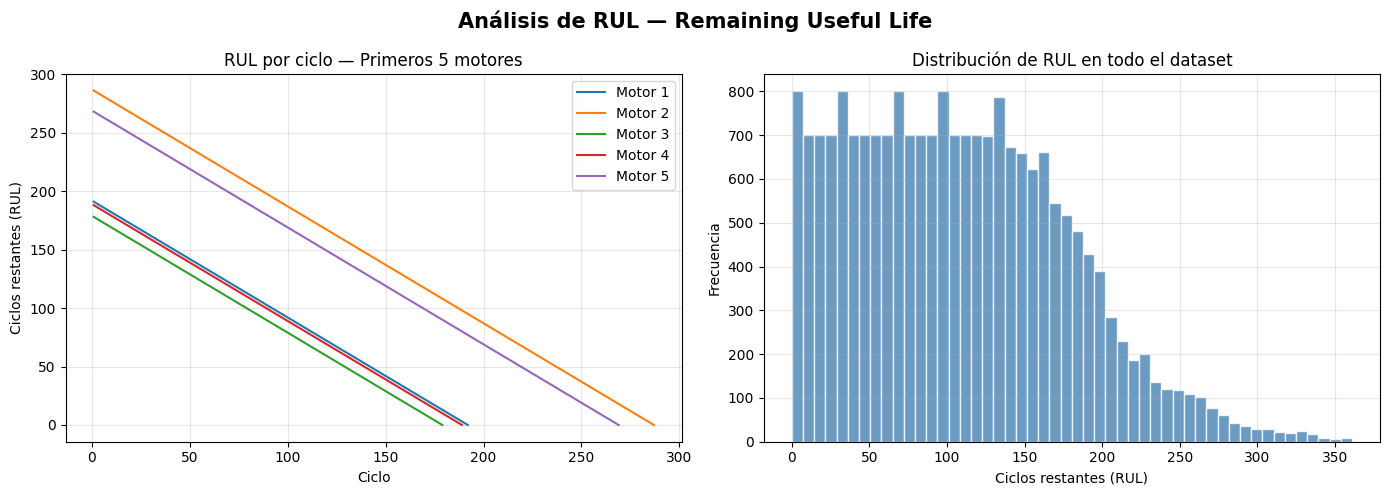

✅ Gráfica guardada en src/


In [3]:
# ============================================
# CELDA 3: Visualización de RUL
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de RUL — Remaining Useful Life', 
             fontsize=15, fontweight='bold')

# Gráfica 1: RUL de 5 motores distintos
ax1 = axes[0]
for unit_id in [1, 2, 3, 4, 5]:
    unit_data = train[train['unit'] == unit_id]
    ax1.plot(unit_data['cycle'], unit_data['RUL'], 
             label=f'Motor {unit_id}', linewidth=1.5)

ax1.set_title('RUL por ciclo — Primeros 5 motores')
ax1.set_xlabel('Ciclo')
ax1.set_ylabel('Ciclos restantes (RUL)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Distribución general de RUL
ax2 = axes[1]
ax2.hist(train['RUL'], bins=50, color='steelblue', 
         edgecolor='white', alpha=0.8)
ax2.set_title('Distribución de RUL en todo el dataset')
ax2.set_xlabel('Ciclos restantes (RUL)')
ax2.set_ylabel('Frecuencia')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/rul_analysis.png', dpi=150)
plt.show()
print("✅ Gráfica guardada en src/")

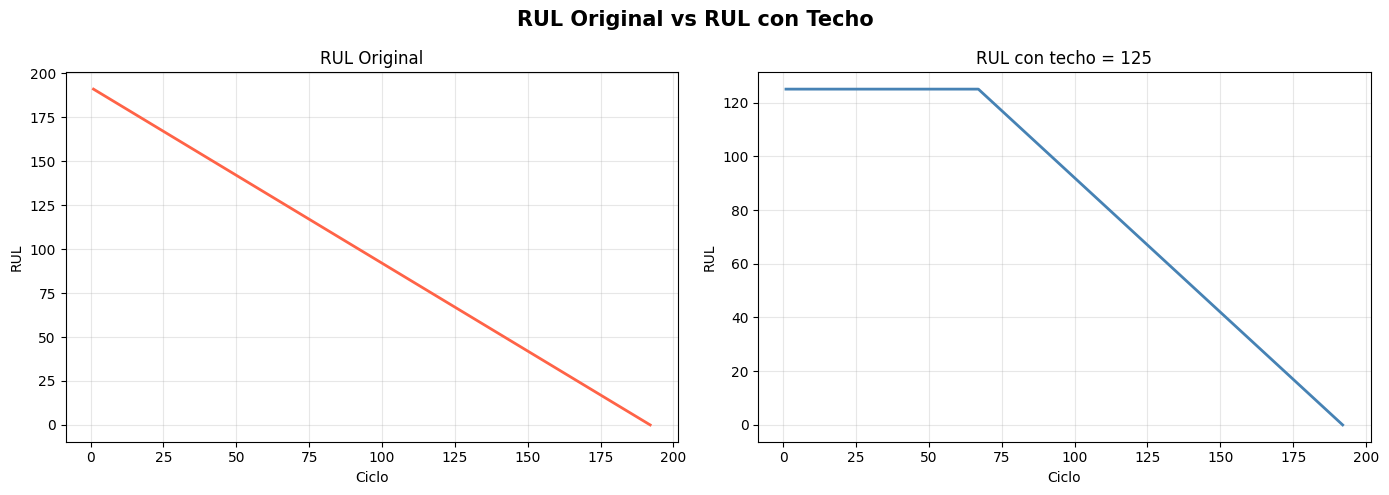

✅ RUL con techo de 125 ciclos creado


In [4]:
# ============================================
# CELDA 4: RUL con techo (Piecewise RUL)
# ============================================

# Problema: al principio de su vida un motor está muy sano
# y los sensores no muestran degradación todavía.
# Ponerle RUL = 300 cuando está nuevo confunde al modelo.

# Solución profesional: poner un techo de 125 ciclos
# Significa: "si le quedan más de 125 ciclos, lo tratamos igual"
# El modelo solo aprende a distinguir la zona de degradación

RUL_CLIP = 125

train['RUL_clipped'] = train['RUL'].clip(upper=RUL_CLIP)

# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RUL Original vs RUL con Techo', 
             fontsize=15, fontweight='bold')

unit_data = train[train['unit'] == 1]

axes[0].plot(unit_data['cycle'], unit_data['RUL'], 
             color='tomato', linewidth=2)
axes[0].set_title('RUL Original')
axes[0].set_xlabel('Ciclo')
axes[0].set_ylabel('RUL')
axes[0].grid(True, alpha=0.3)

axes[1].plot(unit_data['cycle'], unit_data['RUL_clipped'], 
             color='steelblue', linewidth=2)
axes[1].set_title(f'RUL con techo = {RUL_CLIP}')
axes[1].set_xlabel('Ciclo')
axes[1].set_ylabel('RUL')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/rul_clipped.png', dpi=150)
plt.show()
print(f"✅ RUL con techo de {RUL_CLIP} ciclos creado")

In [5]:
# ============================================
# CELDA 5: Normalización de sensores
# ============================================

# Los sensores tienen rangos muy distintos:
# s2 puede valer 600, s4 puede valer 1400
# XGBoost funciona mejor cuando todos están en la misma escala

# Identificamos columnas de sensores y settings
sensor_cols = [f's{i}' for i in range(1, 22) 
               if f's{i}' in train.columns]
setting_cols = ['setting1', 'setting2']
feature_cols = setting_cols + sensor_cols

print(f"📊 Features a normalizar: {len(feature_cols)}")
print(f"   {feature_cols}")

# Aplicamos MinMaxScaler — escala todo entre 0 y 1
scaler = MinMaxScaler()

# IMPORTANTE: el scaler aprende del train, no del test
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])

print("\n✅ Normalización aplicada")
print(f"\nRango después de normalizar:")
print(train[feature_cols].describe().loc[['min', 'max']].round(3))

📊 Features a normalizar: 20
   ['setting1', 'setting2', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

✅ Normalización aplicada

Rango después de normalizar:
     setting1  setting2   s1   s2   s3   s4   s5   s6   s7   s8   s9  s10  \
min       0.0       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
max       1.0       1.0  0.0  1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  0.0   

     s11  s12  s13  s14  s15  s17  s20  s21  
min  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
max  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  


In [6]:
# ============================================
# CELDA 6: Dataset final para modelado
# ============================================

# Dataset de entrenamiento listo
X_train = train[feature_cols]
y_train = train['RUL_clipped']

# Para el test necesitamos el último ciclo de cada motor
# (el momento justo antes de fallar)
X_test = test.groupby('unit').last().reset_index()[feature_cols]
y_test  = rul['RUL']

print("✅ Datasets finales listos")
print(f"\n📊 X_train: {X_train.shape}")
print(f"📊 y_train: {y_train.shape}")
print(f"📊 X_test:  {X_test.shape}")
print(f"📊 y_test:  {y_test.shape}")

# Guardamos para usar en el siguiente notebook
train.to_csv('../data/train_processed.csv', index=False)
test.to_csv('../data/test_processed.csv', index=False)
rul.to_csv('../data/rul_processed.csv', index=False)

print("\n✅ Datos procesados guardados en data/")

✅ Datasets finales listos

📊 X_train: (20631, 20)
📊 y_train: (20631,)
📊 X_test:  (100, 20)
📊 y_test:  (100,)

✅ Datos procesados guardados en data/


In [7]:
# ============================================
# CELDA 7: Resumen
# ============================================

print("=" * 50)
print("RESUMEN — Feature Engineering Completo")
print("=" * 50)
print(f"""
✅ Dataset cargado: {train.shape[0]:,} filas
✅ Variable RUL creada
✅ RUL con techo de {RUL_CLIP} ciclos aplicado
✅ {len(feature_cols)} features normalizados (0 a 1)
✅ X_train: {X_train.shape}
✅ X_test:  {X_test.shape}
✅ Datos procesados guardados

Siguiente paso → 03_model_training.ipynb
""")

RESUMEN — Feature Engineering Completo

✅ Dataset cargado: 20,631 filas
✅ Variable RUL creada
✅ RUL con techo de 125 ciclos aplicado
✅ 20 features normalizados (0 a 1)
✅ X_train: (20631, 20)
✅ X_test:  (100, 20)
✅ Datos procesados guardados

Siguiente paso → 03_model_training.ipynb

